# Reverse convertible pricer (S&P 500)

Prices a 1-year reverse convertible on the S&P 500 from SPX option quotes and finds the fair coupon for a given bank margin.

I built it block by block and tested each block before using it in the next one. Blocks 0-4 only use made-up inputs where I know the answer; market data comes in at block 5. The tests run inside functions so they don't overwrite anything.

Run everything top to bottom (Runtime > Run all).

## Setup

In [23]:
import os, sys, subprocess

try:
    import yfinance as yf
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance"])
    import yfinance as yf

import numpy as np
import pandas as pd
import scipy
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from datetime import date

# copy these into requirements.txt
for name, module in [("numpy", np), ("scipy", scipy), ("pandas", pd), ("matplotlib", matplotlib), ("yfinance", yf)]:
    print(f"{name}=={module.__version__}")

numpy==2.1.3
scipy==1.16.3
pandas==2.2.3
matplotlib==3.10.0
yfinance==0.2.66


### Config

All parameters in one place. The seeds inside the tests are just fixed for the tests, `seed` here is the one used for the final result.

In [24]:
CONFIG = dict(
    margin=0.015,
    expiry="2027-09-30",
    snapshot_file="snapshot_SPX_2027-09-30_2026-09-30.csv",
    github_raw="https://raw.githubusercontent.com/PedroDuque05/reverse-convertible-pricer/main/data/",
    drive_dir="/content/drive/MyDrive/reverse_convertible/dados",
    spread_max=0.10,         # max bid-ask spread relative to mid
    moneyness_window=0.20,   # strikes within 20% of spot
    n_paths=1_000_000,
    seed=11,
)

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

## 0. Conventions

Notional = 1, prices as a fraction of notional, time in years (ACT/365), continuous rates.

At maturity you get 1 + c if the index ends at or above the strike, otherwise the index performance plus the coupon:

`payoff = (1 + c) - max(K - S_T, 0) / K`

Tested against a few cases worked out by hand.

In [25]:
def year_fraction(d0, d1):
    # ACT/365
    return (d1 - d0).days / 365.0

def rc_payoff(ST, S0, K, c):
    # notional 1, works with arrays too
    return (1 + c) - np.maximum(K - ST, 0) / K

In [26]:
def test_block_0():
    S0, K, c = 100.0, 100.0, 0.08
    assert np.isclose(rc_payoff(110, S0, K, c), 1.08)   # up 10%
    assert np.isclose(rc_payoff(100, S0, K, c), 1.08)   # flat
    assert np.isclose(rc_payoff(80,  S0, K, c), 0.88)   # down 20%
    assert np.allclose(rc_payoff(np.array([110, 100, 80]), S0, K, c), [1.08, 1.08, 0.88])

    assert year_fraction(date(2026, 1, 1), date(2027, 1, 1)) == 1.0
    assert np.isclose(year_fraction(date(2026, 1, 1), date(2026, 7, 2)), 182 / 365)
    print("Block 0 OK")

test_block_0()

Block 0 OK


## 1. Black-Scholes

European call/put with a continuous dividend yield.

Checks: Hull's example, put-call parity (exact, so any sign mistake shows up), the zero-vol limit, and the put price going up with vol.

In [27]:
def bs_price(S, K, T, r, q, sigma, kind="put"):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if kind == "call":
        return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    if kind == "put":
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
    raise ValueError("kind must be 'call' or 'put'")

In [28]:
def test_block_1():
    # Hull's example
    assert np.isclose(bs_price(42, 40, 0.5, 0.10, 0.0, 0.20, "call"), 4.76, atol=0.01)
    assert np.isclose(bs_price(42, 40, 0.5, 0.10, 0.0, 0.20, "put"),  0.81, atol=0.01)

    # parity on random inputs
    rng = np.random.default_rng(0)
    n = 1000
    S = rng.uniform(50, 150, n);  K = rng.uniform(50, 150, n)
    T = rng.uniform(0.1, 3, n);   r = rng.uniform(0, 0.08, n)
    q = rng.uniform(0, 0.04, n);  sigma = rng.uniform(0.05, 0.8, n)
    C = bs_price(S, K, T, r, q, sigma, "call")
    P = bs_price(S, K, T, r, q, sigma, "put")
    assert np.allclose(C - P, S * np.exp(-q * T) - K * np.exp(-r * T), atol=1e-10)

    # vol -> 0: put = discounted intrinsic value
    for K_ in [110, 90]:
        p = bs_price(100, K_, 1.0, 0.03, 0.01, 1e-8, "put")
        expected = max(K_ * np.exp(-0.03) - 100 * np.exp(-0.01), 0)
        assert np.isclose(p, expected, atol=1e-6)

    # far OTM put ~ 0
    assert bs_price(100, 20, 1.0, 0.03, 0.01, 0.20, "put") < 1e-8

    # put goes up with vol
    prices = bs_price(100, 100, 1.0, 0.03, 0.01, np.linspace(0.05, 1.0, 50), "put")
    assert np.all(np.diff(prices) > 0)
    print("Block 1 OK")

test_block_1()

Block 1 OK


## 2. Implied volatility

Solves for the vol that matches a given price with Brent's method. The price is strictly increasing in vol (last test above), so there's only one answer. If the price is outside the no-arbitrage bounds it returns NaN.

In the round-trip test I skip prices close to zero, because there the price hardly moves with vol and you can't recover it. Same reason I only use strikes near the money later on.

In [29]:
def implied_vol(price, S, K, T, r, q, kind="put", sig_min=1e-4, sig_max=5.0):
    # returns nan if no vol can match the price
    if kind == "put":
        lower = max(K * np.exp(-r * T) - S * np.exp(-q * T), 0.0)
        upper = K * np.exp(-r * T)
    elif kind == "call":
        lower = max(S * np.exp(-q * T) - K * np.exp(-r * T), 0.0)
        upper = S * np.exp(-q * T)
    else:
        raise ValueError("kind must be 'call' or 'put'")

    if not (lower < price < upper):
        return np.nan

    f = lambda s: bs_price(S, K, T, r, q, s, kind) - price
    if f(sig_min) > 0 or f(sig_max) < 0:
        return np.nan
    return brentq(f, sig_min, sig_max, xtol=1e-12)

In [30]:
def test_block_2():
    # round trip: vol -> price -> vol
    rng = np.random.default_rng(1)
    errors, skipped = [], 0
    for _ in range(500):
        S, T = 100.0, rng.uniform(0.25, 3)
        K = S * rng.uniform(0.7, 1.3)
        r, q = rng.uniform(0, 0.08), rng.uniform(0, 0.04)
        sigma = rng.uniform(0.05, 1.0)
        kind = rng.choice(["put", "call"])
        p = bs_price(S, K, T, r, q, sigma, kind)
        if p < 1e-6:   # price ~ 0, vol can't be recovered
            skipped += 1
            continue
        errors.append(abs(implied_vol(p, S, K, T, r, q, kind) - sigma))
    assert max(errors) < 1e-6
    print(f"Round trip: max error = {max(errors):.2e} | skipped = {skipped}")

    # impossible prices
    S, K, T, r, q = 100, 120, 1.0, 0.03, 0.01
    assert np.isnan(implied_vol(10,  S, K, T, r, q, "put"))   # below intrinsic
    assert np.isnan(implied_vol(200, S, K, T, r, q, "put"))   # above max possible
    assert np.isnan(implied_vol(-1,  S, K, T, r, q, "put"))

    # call and put with the same vol give the same vol back
    for kind in ["call", "put"]:
        p = bs_price(100, 100, 1.0, 0.04, 0.013, 0.18, kind)
        assert np.isclose(implied_vol(p, 100, 100, 1.0, 0.04, 0.013, kind), 0.18, atol=1e-8)
    print("Block 2 OK")

test_block_2()

Round trip: max error = 2.71e-08 | skipped = 1
Block 2 OK


## 3. Monte Carlo

`simulate_ST` generates terminal prices under risk-neutral GBM and `mc_estimate` discounts and averages. I kept them separate so each one can be tested on its own.

Tolerance is 4 standard errors, so a correct version should basically never fail by chance.

In [31]:
def simulate_ST(S, T, r, q, sigma, n, seed):
    # risk-neutral GBM
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(n)
    return S * np.exp((r - q - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

def mc_estimate(payoffs, r, T):
    # price, std error, 95% CI
    disc = np.exp(-r * T) * payoffs
    price = disc.mean()
    se = disc.std(ddof=1) / np.sqrt(len(disc))
    return price, se, (price - 1.96 * se, price + 1.96 * se)

In [32]:
def test_block_3():
    S, T, r, q, sigma, n = 100.0, 1.0, 0.04, 0.013, 0.18, 1_000_000
    ST = simulate_ST(S, T, r, q, sigma, n, seed=42)

    # mean of S_T = forward
    assert abs(ST.mean() - S * np.exp((r - q) * T)) < 4 * ST.std(ddof=1) / np.sqrt(n)

    # mean and std of ln(S_T)
    lnST = np.log(ST)
    assert abs(lnST.mean() - (np.log(S) + (r - q - 0.5 * sigma**2) * T)) < 4 * sigma * np.sqrt(T) / np.sqrt(n)
    assert abs(lnST.std(ddof=1) - sigma * np.sqrt(T)) < 4 * sigma * np.sqrt(T) / np.sqrt(2 * n)

    # MC put vs BS put
    for K in [90, 100, 110]:
        mc, se, _ = mc_estimate(np.maximum(K - ST, 0), r, T)
        bs = bs_price(S, K, T, r, q, sigma, "put")
        print(f"K={K}: MC={mc:.4f} ± {1.96*se:.4f} | BS={bs:.4f}")
        assert abs(mc - bs) < 4 * se

    # 4x paths -> half the std error
    _, se1, _ = mc_estimate(np.maximum(100 - simulate_ST(S, T, r, q, sigma, 100_000, seed=1), 0), r, T)
    _, se4, _ = mc_estimate(np.maximum(100 - simulate_ST(S, T, r, q, sigma, 400_000, seed=2), 0), r, T)
    print(f"Std error ratio (should be ~2): {se1/se4:.3f}")
    assert 1.8 < se1 / se4 < 2.2

    # same seed, same paths
    assert np.array_equal(simulate_ST(S, T, r, q, sigma, 1000, seed=7),
                          simulate_ST(S, T, r, q, sigma, 1000, seed=7))
    print("Block 3 OK")

test_block_3()

K=90: MC=2.2318 ± 0.0099 | BS=2.2319
K=100: MC=5.7469 ± 0.0165 | BS=5.7478
K=110: MC=11.3381 ± 0.0229 | BS=11.3379
Std error ratio (should be ~2): 1.994
Block 3 OK


## 4. The product

A bond paying 1 + c minus a put (scaled by 1/K):

`value = (1 + c) * exp(-rT) - P/K`

The bank sells at 100 and keeps m, so the fair coupon is:

`c = (1 - m + P/K) * exp(rT) - 1`

Checks: MC on the full payoff matches the formula, the fair coupon gives back exactly 1 - m, and the coupon behaves sensibly (above the risk-free rate, going up with vol). After this block everything works without having touched market data.

In [33]:
def rc_value_analytic(c, P, K, r, T):
    # bond minus put
    return (1 + c) * np.exp(-r * T) - P / K

def fair_coupon(P, K, r, T, m):
    # coupon that makes the product worth 1 - m
    return (1 - m + P / K) * np.exp(r * T) - 1

def rc_value_mc(c, S, K, T, r, q, sigma, n, seed):
    ST = simulate_ST(S, T, r, q, sigma, n, seed)
    return mc_estimate(rc_payoff(ST, S, K, c), r, T)

In [34]:
def test_block_4():
    S, T, r, q, sigma, m = 100.0, 1.0, 0.04, 0.013, 0.18, CONFIG["margin"]

    # MC on the full payoff vs bond - put
    for K in [90, 100, 110]:
        P = bs_price(S, K, T, r, q, sigma, "put")
        analytic = rc_value_analytic(0.08, P, K, r, T)
        mc, se, _ = rc_value_mc(0.08, S, K, T, r, q, sigma, 1_000_000, seed=42)
        print(f"K={K}: MC={mc:.5f} ± {1.96*se:.5f} | analytic={analytic:.5f}")
        assert abs(mc - analytic) < 4 * se

    # fair coupon gives back 1 - m
    P = bs_price(S, 100, T, r, q, sigma, "put")
    c = fair_coupon(P, 100, r, T, m)
    assert np.isclose(rc_value_analytic(c, P, 100, r, T), 1 - m, atol=1e-14)
    print(f"Fair coupon (synthetic example): {c:.4%}")

    # same thing with MC
    mc, se, _ = rc_value_mc(c, S, 100, T, r, q, sigma, 1_000_000, seed=3)
    assert abs(mc - (1 - m)) < 4 * se

    # coupon above risk-free rate and increasing with vol
    assert c > np.exp(r * T) - 1
    coupons = [fair_coupon(bs_price(S, 100, T, r, q, s, "put"), 100, r, T, m) for s in np.linspace(0.05, 0.60, 30)]
    assert np.all(np.diff(coupons) > 0)
    print("Block 4 OK")

test_block_4()

K=90: MC=1.01286 ± 0.00011 | analytic=1.01285
K=100: MC=0.98018 ± 0.00016 | analytic=0.98017
K=110: MC=0.93458 ± 0.00021 | analytic=0.93458
Fair coupon (synthetic example): 8.5023%
Block 4 OK


## 5. Market data

Everything runs off a saved snapshot of SPX quotes, so the numbers don't change. It looks for the file in `data/`, then in the GitHub repo, then in my Google Drive.

`create_snapshot()` downloads new quotes from Yahoo, but it isn't called anywhere; you have to run it yourself.

Filters: bid > 0, ask > bid, spread under 10% of mid. I don't filter on open interest since it's very low for options this long anyway.

In [35]:
def create_snapshot(expiry, out_dir="data"):
    # downloads spot + option chain and saves a dated csv (not called automatically)
    os.makedirs(out_dir, exist_ok=True)
    spx = yf.Ticker("^SPX")
    hist = spx.history(period="5d")
    chain = spx.option_chain(expiry)
    snap = pd.concat([chain.calls.assign(type="call"), chain.puts.assign(type="put")], ignore_index=True)
    snap = snap[["type", "strike", "bid", "ask", "volume", "openInterest", "lastTradeDate"]]
    snap["spot"] = hist["Close"].iloc[-1]
    snap["spot_date"] = hist.index[-1].date()
    snap["expiry"] = expiry
    snap["snapshot_date"] = date.today()
    path = os.path.join(out_dir, f"snapshot_SPX_{expiry}_{date.today():%Y-%m-%d}.csv")
    snap.to_csv(path, index=False)
    print("Snapshot saved:", path)
    return path

def load_snapshot(filename):
    # data/ first, then github, then drive
    local = os.path.join("data", filename)
    if os.path.exists(local):
        df, source = pd.read_csv(local), local
    else:
        df = None
        try:
            df, source = pd.read_csv(CONFIG["github_raw"] + filename), "GitHub"
        except Exception:
            try:
                from google.colab import drive
                drive.mount("/content/drive")
                path = os.path.join(CONFIG["drive_dir"], filename)
                if os.path.exists(path):
                    df, source = pd.read_csv(path), "Google Drive"
            except ImportError:
                pass
        if df is None:
            raise FileNotFoundError(f"{filename} not found, run create_snapshot(CONFIG['expiry']) to make a new one")
    print("Snapshot loaded from:", source)
    # my first snapshot has the column names in portuguese
    return df.rename(columns={"tipo": "type", "data_spot": "spot_date",
                              "expiracao": "expiry", "data_snapshot": "snapshot_date"})

def filter_quotes(df, spread_max):
    df = df.copy()
    df["mid"] = (df["bid"] + df["ask"]) / 2
    df["spread_rel"] = (df["ask"] - df["bid"]) / df["mid"]
    ok = (df["bid"] > 0) & (df["ask"] > df["bid"]) & (df["spread_rel"] < spread_max)
    return df[ok]

def build_pairs(clean, S0, window):
    # call and put at the same strike, near the money
    calls = clean[clean.type == "call"][["strike", "mid", "bid", "ask"]]
    puts  = clean[clean.type == "put"][["strike", "mid", "bid", "ask"]]
    pairs = calls.merge(puts, on="strike", suffixes=("_c", "_p"))
    pairs = pairs[(pairs.strike > (1 - window) * S0) & (pairs.strike < (1 + window) * S0)]
    return pairs.sort_values("strike").reset_index(drop=True)

In [36]:
quotes = load_snapshot(CONFIG["snapshot_file"])

snapshot_date = pd.to_datetime(quotes["snapshot_date"].iloc[0]).date()
expiry_date = pd.to_datetime(quotes["expiry"].iloc[0]).date()
S0 = float(quotes["spot"].iloc[0])
T = year_fraction(snapshot_date, expiry_date)

clean = filter_quotes(quotes, CONFIG["spread_max"])
pairs = build_pairs(clean, S0, CONFIG["moneyness_window"])

print(f"Spot: {S0:.2f} (close of {quotes['spot_date'].iloc[0]}) | T = {T:.4f} years")
print(f"Quotes: {len(quotes)} total | {len(clean)} valid | {len(pairs)} call-put pairs near the money")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Snapshot loaded from: Google Drive
Spot: 7670.84 (close of 2026-09-29) | T = 1.0000 years
Quotes: 139 total | 129 valid | 32 call-put pairs near the money


In [37]:
def test_block_5(clean, pairs, T):
    # nothing invalid got through
    assert (clean.bid > 0).all() and (clean.ask > clean.bid).all() and (clean.spread_rel < CONFIG["spread_max"]).all()

    # roughly 1 year
    assert 0.9 < T < 1.1

    # enough pairs for the regression
    assert len(pairs) >= 5

    # calls fall and puts rise with the strike
    assert (np.diff(pairs.mid_c) < 0).all(), "calls not decreasing in strike"
    assert (np.diff(pairs.mid_p) > 0).all(), "puts not increasing in strike"
    print("Block 5 OK")

test_block_5(clean, pairs, T)

Block 5 OK


## 6. Forward and implied vol

Put-call parity: C - P = D*F - D*K, a straight line in K. Regressing it over the pairs gives D and F, so I don't need an outside rate or dividend yield. R² will be close to 1 anyway since parity has to hold; the real check is whether the line stays inside bid-ask.

It also fixes a timing issue: my spot is the previous day's close, but S0*exp(-qT) = D*F only depends on the options, so the price isn't affected. The implied q itself is less reliable though.

Vols come from mid prices. The spot isn't a listed strike, so I interpolate between the two closest ones. If r and q are right, put and call vols at the same strike should match.

In [38]:
def implied_forward(pairs, T, S0):
    # regress C - P on K: slope = -D, intercept = D*F
    x = pairs.strike.values
    y = (pairs.mid_c - pairs.mid_p).values
    slope, intercept = np.polyfit(x, y, 1)
    D = -slope
    F = intercept / D
    r = -np.log(D) / T
    q = r - np.log(F / S0) / T
    fitted = intercept + slope * x
    R2 = 1 - np.sum((y - fitted)**2) / np.sum((y - y.mean())**2)
    return dict(D=D, F=F, r=r, q=q, R2=R2, fitted=fitted, resid=y - fitted)

fwd = implied_forward(pairs, T, S0)
D, F, r_imp, q_imp = fwd["D"], fwd["F"], fwd["r"], fwd["q"]
print(f"D = {D:.5f} | r = {r_imp:.4%} | F = {F:.2f} | q = {q_imp:.4%} | R² = {fwd['R2']:.7f}")
print(f"Residuals: max = {np.abs(fwd['resid']).max():.2f} | std = {np.std(fwd['resid']):.2f}")

vols_p = np.array([implied_vol(row.mid_p, S0, row.strike, T, r_imp, q_imp, "put")  for row in pairs.itertuples()])
vols_c = np.array([implied_vol(row.mid_c, S0, row.strike, T, r_imp, q_imp, "call") for row in pairs.itertuples()])
sigma_atm = np.interp(S0, pairs.strike.values, vols_p)
print(f"Vol at the product strike (K = spot = {S0:.2f}): {sigma_atm:.4%}")

D = 0.95136 | r = 4.9860% | F = 7996.18 | q = 0.8322% | R² = 0.9999978
Residuals: max = 0.95 | std = 0.50
Vol at the product strike (K = spot = 7670.84): 17.5411%


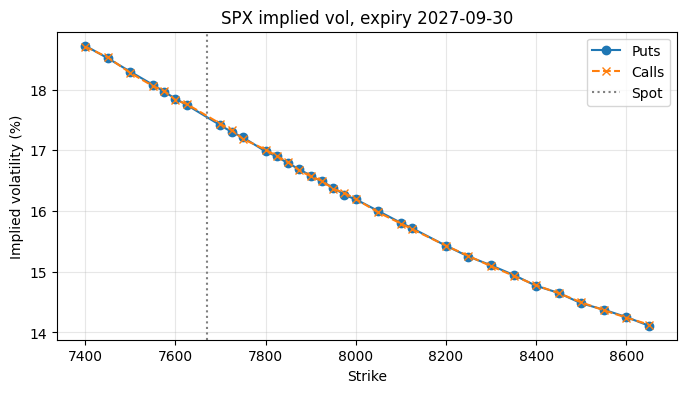

In [39]:
plt.figure(figsize=(8, 4))
plt.plot(pairs.strike, vols_p * 100, "o-", label="Puts")
plt.plot(pairs.strike, vols_c * 100, "x--", label="Calls")
plt.axvline(S0, color="grey", ls=":", label="Spot")
plt.xlabel("Strike"); plt.ylabel("Implied volatility (%)")
plt.title(f"SPX implied vol, expiry {expiry_date}")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(os.path.join(FIG_DIR, "smile.png"), dpi=150, bbox_inches="tight")
plt.show()

In [40]:
def test_block_6(pairs, fwd, vols_p, vols_c, sigma_atm):
    # R2 (should be ~1 anyway)
    assert fwd["R2"] > 0.9999

    # fitted line inside bid-ask of C - P
    lower = (pairs.bid_c - pairs.ask_p).values
    upper = (pairs.ask_c - pairs.bid_p).values
    inside = (fwd["fitted"] >= lower) & (fwd["fitted"] <= upper)
    print(f"Fit inside bid-ask: {inside.mean():.0%} of pairs")
    assert inside.mean() >= 0.90

    # sanity ranges
    assert 0.90 < fwd["D"] < 1.0
    assert 0.02 < fwd["r"] < 0.07
    assert 0.0 < fwd["q"] < 0.03

    # no missing vols
    assert not np.isnan(vols_p).any() and not np.isnan(vols_c).any()

    # put and call vols should match (within 1 vol point)
    print(f"Max put/call vol difference: {np.abs(vols_p - vols_c).max()*100:.3f} vol pts")
    assert np.abs(vols_p - vols_c).max() < 0.01

    assert 0.10 < sigma_atm < 0.40

    # skew: low strikes have higher vol
    assert vols_p[0] > vols_p[-1]
    print("Block 6 OK")

test_block_6(pairs, fwd, vols_p, vols_c, sigma_atm)

Fit inside bid-ask: 100% of pairs
Max put/call vol difference: 0.031 vol pts
Block 6 OK


## 7. Result

Fair coupon with market inputs, split into interest + put premium - margin.

Last checks: the model put should land between the market puts on either side, and MC at the fair coupon should give 1 - m. That one uses blocks 3 to 6 together.

In [41]:
m = CONFIG["margin"]
K_prod = S0   # ATM

P_prod = bs_price(S0, K_prod, T, r_imp, q_imp, sigma_atm, "put")
c_fair = fair_coupon(P_prod, K_prod, r_imp, T, m)

interest = 1 / D - 1
premium  = (P_prod / K_prod) / D
margin   = m / D

print(f"Put at the product strike: {P_prod:.2f} ({P_prod/K_prod:.3%} of notional)")
print(f"Fair coupon: {c_fair:.3%}")
print(f"  = interest {interest:.2%} + put premium {premium:.2%} - margin {margin:.2%}")

Put at the product strike: 380.59 (4.961% of notional)
Fair coupon: 8.751%
  = interest 5.11% + put premium 5.22% - margin 1.58%


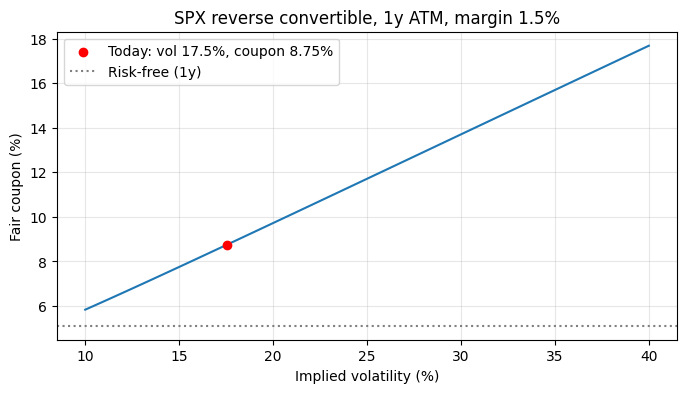

In [42]:
sigmas = np.linspace(0.10, 0.40, 61)
coupons = [fair_coupon(bs_price(S0, K_prod, T, r_imp, q_imp, s, "put"), K_prod, r_imp, T, m) for s in sigmas]

plt.figure(figsize=(8, 4))
plt.plot(sigmas * 100, np.array(coupons) * 100)
plt.scatter([sigma_atm * 100], [c_fair * 100], color="red", zorder=3,
            label=f"Today: vol {sigma_atm:.1%}, coupon {c_fair:.2%}")
plt.axhline(interest * 100, color="grey", ls=":", label="Risk-free (1y)")
plt.xlabel("Implied volatility (%)"); plt.ylabel("Fair coupon (%)")
plt.title(f"SPX reverse convertible, 1y ATM, margin {m:.1%}")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(os.path.join(FIG_DIR, "coupon_vs_vol.png"), dpi=150, bbox_inches="tight")
plt.show()

In [43]:
def test_block_7(pairs, S0, P_prod, c_fair, coupons):
    # model put between the market puts on either side
    K_below = pairs.strike[pairs.strike <= S0].max()
    K_above = pairs.strike[pairs.strike >= S0].min()
    assert not (np.isnan(K_below) or np.isnan(K_above)), "spot outside the strike range"
    P_below = pairs.loc[pairs.strike == K_below, "mid_p"].iloc[0]
    P_above = pairs.loc[pairs.strike == K_above, "mid_p"].iloc[0]
    print(f"Market puts: K={K_below:.0f} -> {P_below:.2f} | K={K_above:.0f} -> {P_above:.2f} | model: {P_prod:.2f}")
    assert P_below <= P_prod <= P_above

    # MC at the fair coupon should give 1 - m
    mc, se, _ = rc_value_mc(c_fair, S0, S0, T, r_imp, q_imp, sigma_atm, CONFIG["n_paths"], CONFIG["seed"])
    print(f"MC value = {mc:.5f} ± {1.96*se:.5f} | target = {1 - m:.5f}")
    assert abs(mc - (1 - m)) < 4 * se

    # coupon above interest and increasing with vol
    assert c_fair > interest
    assert np.all(np.diff(coupons) > 0)

    # decomposition adds up
    assert np.isclose(c_fair, interest + premium - margin, atol=1e-12)
    print("Block 7 OK")

test_block_7(pairs, S0, P_prod, c_fair, coupons)

Market puts: K=7625 -> 367.50 | K=7700 -> 389.15 | model: 380.59
MC value = 0.98504 ± 0.00015 | target = 0.98500
Block 7 OK


## Summary

In [44]:
print(f"Snapshot: {snapshot_date} | expiry {expiry_date} | spot {S0:.2f}")
print(f"Implied r = {r_imp:.2%} | implied q = {q_imp:.2%} | vol at strike = {sigma_atm:.2%}")
print(f"Fair coupon, 1-year ATM reverse convertible, margin {m:.1%}: {c_fair:.2%}")
print(f"  = {interest:.2%} interest + {premium:.2%} put premium - {margin:.2%} margin")
print("All blocks passed.")

Snapshot: 2026-09-30 | expiry 2027-09-30 | spot 7670.84
Implied r = 4.99% | implied q = 0.83% | vol at strike = 17.54%
Fair coupon, 1-year ATM reverse convertible, margin 1.5%: 8.75%
  = 5.11% interest + 5.22% put premium - 1.58% margin
All blocks passed.


In [45]:
import shutil
destino = "/content/drive/MyDrive/reverse_convertible/figures"
os.makedirs(destino, exist_ok=True)
for f in ["smile.png", "coupon_vs_vol.png"]:
    shutil.copy(os.path.join(FIG_DIR, f), destino)
print(os.listdir(destino))

['smile.png', 'coupon_vs_vol.png']
